In [1]:
import sys
sys.path.append('../')
from model.VQAE import VQAE
from model.MARL import MARL
from utils import device, add_noise
from tqdm import tqdm
import torch
from data.FloorPlanLoader import *
import torch.nn.functional as F
import random
import json
import torchvision
import matplotlib.pyplot as plt
import geopandas as gpd

USE_MULTISCALE = True
USE_MULTITASK = True

#Reproducability Checks:
random.seed(0) #Python
torch.manual_seed(0) #Torch
np.random.seed(0) #NumPy


import torchvision
import torchvision.transforms.functional as TF
import imageio
from torchvision.utils import save_image
# %load_ext autoreload
# %autoreload 2
import csv
import numpy
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
from mpl_toolkits import mplot3d
from sklearn.cluster import KMeans
from sklearn.metrics import pairwise_distances_argmin_min
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans
from umap import UMAP
import matplotlib.pyplot as plt
# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device = 'cpu'

In [2]:
#Hyperparameter
device = torch.device('cpu')
batch_size = 128
n_hiddens = 32
n_residual_hiddens = 32
n_residual_layers = 1
embedding_dim = 64
n_embeddings = 218
beta = .25
lr = 3e-3
epochs = 100
noise=False
noise_weight=0.05
img_channel=3 if USE_MULTISCALE else 1

### prepare latent.pt file

In [4]:
#Load Dataset
curr_data = 'dataTRSATRT'
floor = FloorPlanDataset(multi_scale=True, root=f'../data/data_root_1/data_tert_5/',\
                         data_config='../data/data_config/tertiary', preprocess=True)
data_loader = torch.utils.data.DataLoader(floor, batch_size=batch_size, shuffle=False)
vqae = VQAE(n_hiddens, n_residual_hiddens, n_residual_layers,
            n_embeddings, embedding_dim, 
            beta, img_channel).to(device)

marl = MARL(vqae, True, floor.age_label_num, floor.category_num).to(device)
marl.load_state_dict(torch.load("../checkpoint/last-marl.pt", map_location=torch.device('cpu')))
# print(f"data shape: {floor[0]['image_tensor'].shape}, dataset size: {len(floor)}")
for param in vqae.parameters():
    param.to('cpu')
for param in marl.parameters():
    param.to('cpu')

# marl.eval()
# latents = None
# with torch.no_grad():
#     for data in tqdm(data_loader):
#         data = data['image_tensor'].to(device)
#         valid_recon = marl(data)
#         quantized = valid_recon['latent']
#         if latents is not None:
#             latents = torch.cat([latents, quantized], dim=0)
#         else: 
#             latents = quantized
# latent_file_path = f'../data/data_root/marl_latent_{curr_data}.pt'
# print(f"finished latents configuration, now saving to {latent_file_path} ...")
# torch.save(latents, latent_file_path)
# print(f"latent saved to {latent_file_path} ...")

# Embedding Space Visualization
## Visualize the latent with UMAP and T-SNE

In [5]:
latent_file_path = '../data/data_root_1/data_tert_5/'
pt_files = [f for f in os.listdir(latent_file_path) if f.endswith('.pt')]

# Load each file into a list
latents = [torch.load(os.path.join(latent_file_path, f)) for f in pt_files]
floor = FloorPlanDataset(multi_scale=True, root=f'../data/data_root_1/data_tert_5/',\
                         data_config='../data/data_config/tertiary/', preprocess=True)
data_loader = torch.utils.data.DataLoader(floor, batch_size=batch_size, shuffle=False)


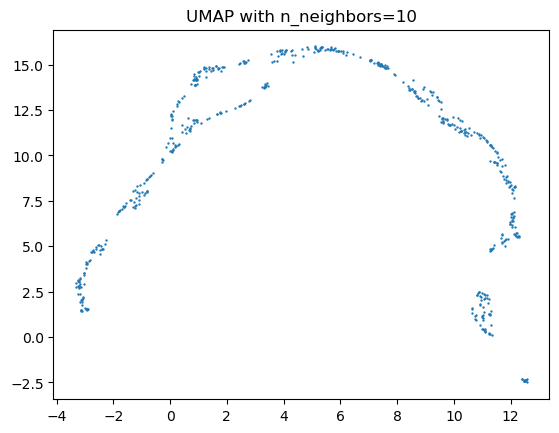

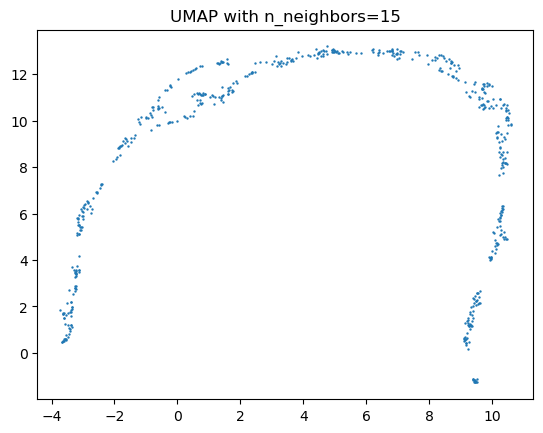

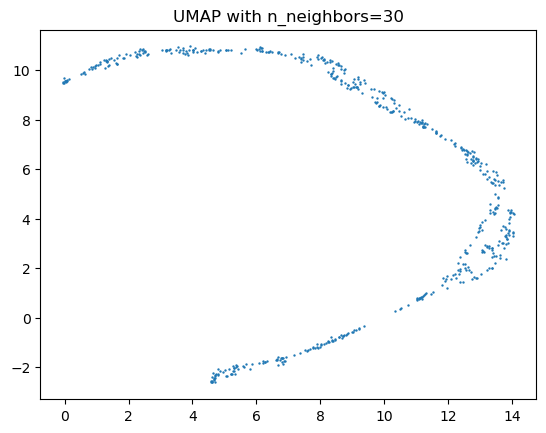

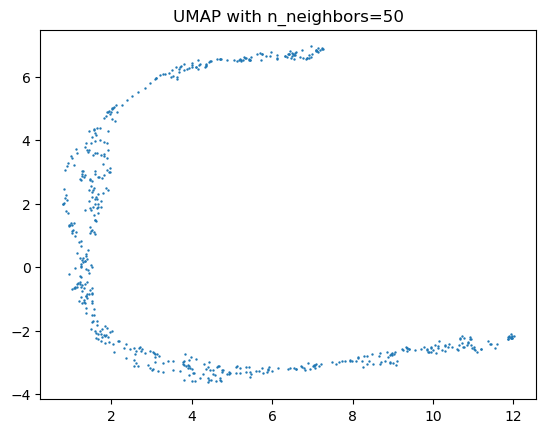

In [6]:
import matplotlib.pyplot as plt
from umap import UMAP
import torch

latents = torch.stack(latents)  # assuming latents is a list of tensors

neighbors_list = [10, 15, 30, 50]

for n_neighbors in neighbors_list:
    umap = UMAP(n_neighbors=n_neighbors, n_components=2)
    data_2d_umap = umap.fit_transform(torch.flatten(latents, start_dim=1).cpu())

    fig = plt.figure()
    ax = fig.add_subplot(111)
    ax.scatter(data_2d_umap[:, 0], data_2d_umap[:, 1], s=0.5)
    ax.set_title(f'UMAP with n_neighbors={n_neighbors}')
    plt.show()





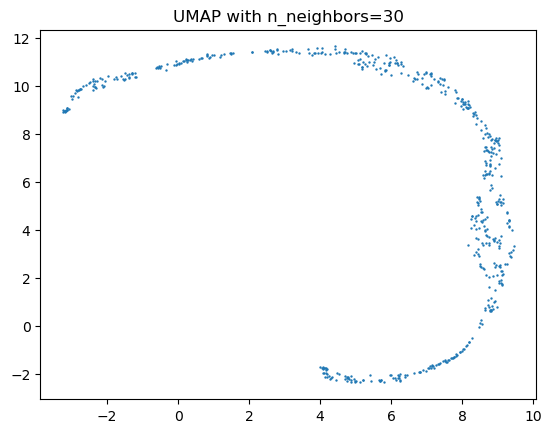

In [11]:
latent_file_path = '../data/data_root_1/data_tert_5/'
pt_files = [f for f in os.listdir(latent_file_path) if f.endswith('.pt')]

# Load each file into a list
latents = [torch.load(os.path.join(latent_file_path, f)) for f in pt_files]
floor = FloorPlanDataset(multi_scale=True, root=f'../data/data_root_1/data_tert_5/',\
                         data_config='../data/data_config/tertiary/', preprocess=True)
data_loader = torch.utils.data.DataLoader(floor, batch_size=batch_size, shuffle=False)
latents = torch.stack(latents)  # assuming latents is a list of tensors

# Flatten latents for UMAP
latents_flat = torch.flatten(latents, start_dim=1).cpu()

# Run UMAP with n_neighbors=15
umap = UMAP(n_neighbors=30, n_components=2)
data_2d_umap = umap.fit_transform(latents_flat)

# Plot
fig = plt.figure()
ax = fig.add_subplot(111)
ax.scatter(data_2d_umap[:, 0], data_2d_umap[:, 1], s=0.5)
ax.set_title('UMAP with n_neighbors=30')
plt.show()



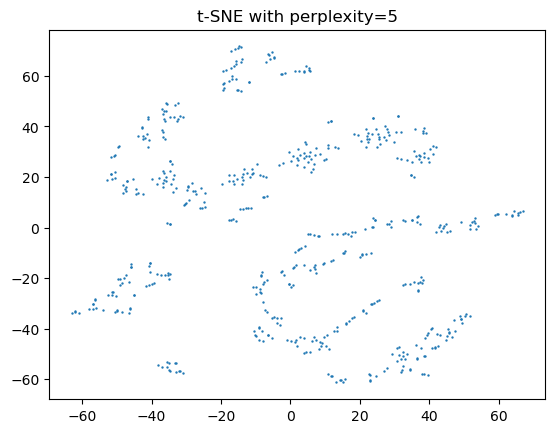

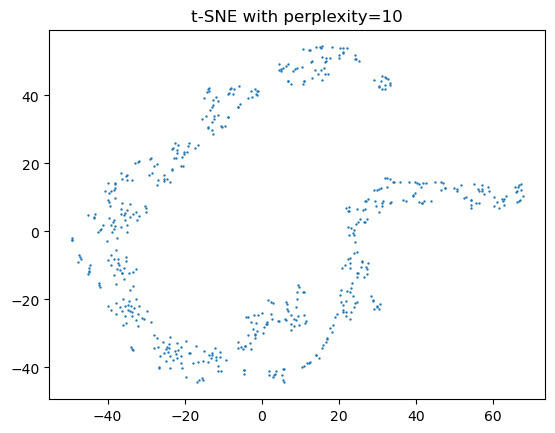

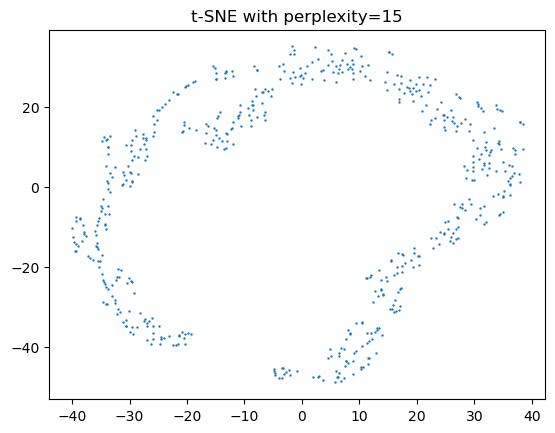

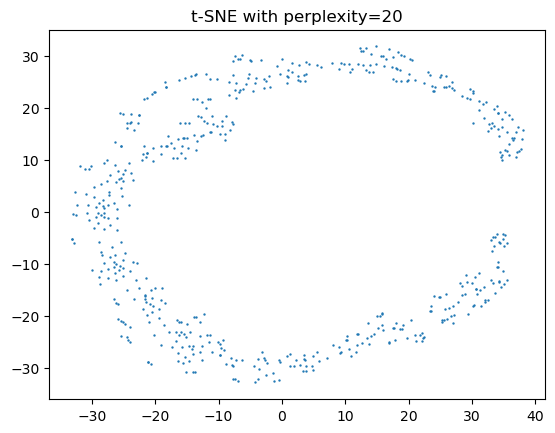

In [8]:
latent_file_path = '../data/data_root_1/data_tert_5/'
pt_files = [f for f in os.listdir(latent_file_path) if f.endswith('.pt')]

# Load each file into a list
latents = [torch.load(os.path.join(latent_file_path, f)) for f in pt_files]
floor = FloorPlanDataset(multi_scale=True, root=f'../data/data_root_1/data_tert_5/',\
                         data_config='../data/data_config/tertiary/', preprocess=True)
data_loader = torch.utils.data.DataLoader(floor, batch_size=batch_size, shuffle=False)

latents = torch.stack(latents)  # assuming latents is a list of tensors

perplexities = [5,10,15,20]

for perplexity in perplexities:
    tsne = TSNE(n_components=2, perplexity=perplexity, init='random', random_state=42)
    data_2d_tsne = tsne.fit_transform(torch.flatten(latents, start_dim=1).cpu())

    fig = plt.figure()
    ax = fig.add_subplot(111)
    ax.scatter(data_2d_tsne[:, 0], data_2d_tsne[:, 1], s=0.5)
    ax.set_title(f't-SNE with perplexity={perplexity}')
    plt.show()

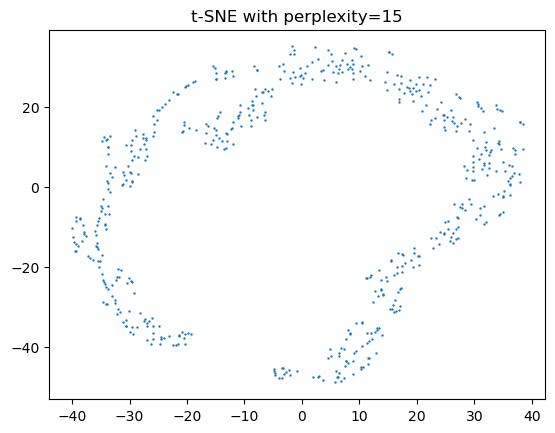

In [35]:
latent_file_path = '../data/data_root_1/data_tert_5/'
pt_files = [f for f in os.listdir(latent_file_path) if f.endswith('.pt')]

# Load each file into a list
latents = [torch.load(os.path.join(latent_file_path, f)) for f in pt_files]
floor = FloorPlanDataset(multi_scale=True, root=f'../data/data_root_1/data_tert_5/',\
                         data_config='../data/data_config/tertiary/', preprocess=True)
data_loader = torch.utils.data.DataLoader(floor, batch_size=batch_size, shuffle=False)

latents = torch.stack(latents)  # assuming latents is a list of tensors # assuming latents is a list of tensors

# Flatten latents for t-SNE
latents_flat = torch.flatten(latents, start_dim=1).cpu()

# Run t-SNE with perplexity=15
tsne = TSNE(n_components=2, perplexity=15, init='random', random_state=42)
data_2d_tsne = tsne.fit_transform(latents_flat)

# Plot
fig = plt.figure()
ax = fig.add_subplot(111)
ax.scatter(data_2d_tsne[:, 0], data_2d_tsne[:, 1], s=0.5)
ax.set_title('t-SNE with perplexity=15')
plt.show()


### deciding the number of clusters

In [36]:
def calculate_wcss(latents):
    wcss = []
    for n in tqdm(range(1, 7)):  # change the range according to your needs
        kmeans = KMeans(n_clusters=n)
        data = torch.flatten(latents, start_dim=1).cpu()
        kmeans.fit(data)
        wcss.append(kmeans.inertia_)  # inertia_ is the WCSS for the model
    return wcss
# calculate WCSS for different numbers of clusters
wcss = calculate_wcss(latents)

100%|██████████| 6/6 [00:02<00:00,  2.88it/s]


In [37]:
# Convert list to DataFrame
wcss_df = pd.DataFrame(wcss)
wcss_df.to_csv(f'wcss_{curr_data}.csv',index=False)
wcss_df

,0
0,490773.166382
1,397636.483698
2,349083.880793
3,314117.575586
4,292279.644143
5,271585.551721


In [38]:
def plot_elbow(wcss, filename=None):
    plt.figure(figsize=(10, 5))
    plt.plot(range(1, len(wcss) + 1), wcss, 'bo-')
    plt.title('The Elbow Method')
    plt.xlabel('Number of clusters')
    plt.ylabel('WCSS')
    plt.grid()
    filename = 'elbow plot for k-means'
    plt.savefig(filename)

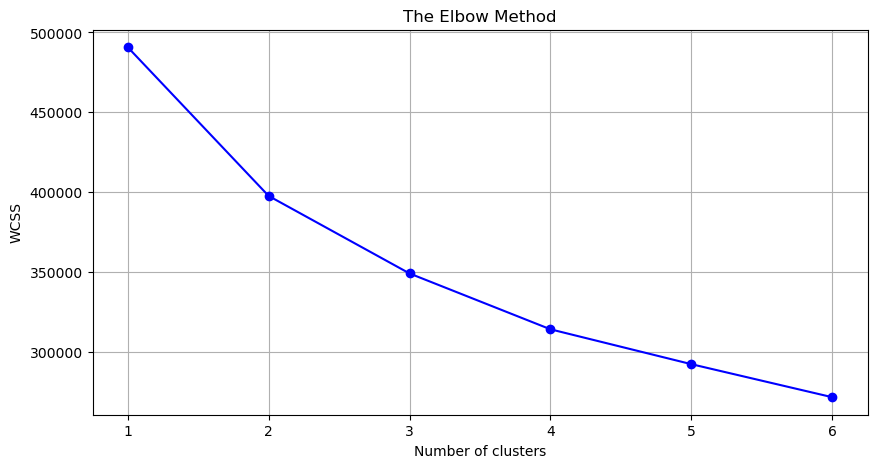

In [39]:
# plot the elbow graph
plot_elbow(wcss)

the number of clusters are set to 5, 10, 15

In [40]:
def calculate_slope(points):
    slopes = []
    for i in range(len(points) - 1):
        slope = (points[i + 1] - points[i]) / (i + 2 - i)
        slopes.append(slope)
    return slopes

def find_optimal_point(slopes, drop_threshold=0.1):
    optimal_point = 1
    for i in range(len(slopes)):
        if slopes[i] / slopes[i - 1] <= drop_threshold:
            optimal_point = i + 1
            break
    return optimal_point

In [41]:
# Calculate slopes
slopes = calculate_slope(wcss)
print(slopes)
# Find the optimal point based on the slope
optimal_point = find_optimal_point(slopes)

print("Optimal point:", optimal_point)

[-46568.34134186627, -24276.301452712738, -17483.152603413095, -10918.96572143343, -10347.04621102786]
Optimal point: 1


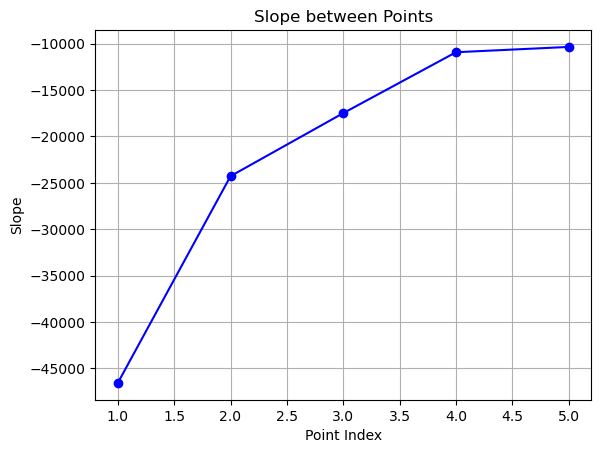

In [42]:
# Plot the slopes
plt.plot(range(1, len(wcss)), slopes, 'bo-')
plt.title('Slope between Points')
plt.xlabel('Point Index')
plt.ylabel('Slope')
plt.grid()
plt.show()

In [43]:
from kneed import KneeLocator

K = range(1, len(wcss) + 1)
kneedle = KneeLocator(K, wcss, curve='convex', direction='decreasing')
print("Optimal number of clusters:", kneedle.knee)
print(wcss)



Optimal number of clusters: 3
[490773.1663821743, 397636.48369844176, 349083.8807930163, 314117.5755861901, 292279.64414332324, 271585.5517212675]


### Clustering

MF CLUSTER = 4 \
SF CLUSTER = 4

In [44]:
n_clusters= kneedle.knee
data_latent = latents # this is the data for clustering
print(n_clusters)

3


In [45]:
#Initialize the class object
kmeans = KMeans(n_clusters=n_clusters)
data = torch.flatten(data_latent, start_dim=1).cpu()
# #predict the labels of clusters.
label = kmeans.fit_predict(data)
# get cluster centers
cluster_centers = kmeans.cluster_centers_
closest, _ = pairwise_distances_argmin_min(cluster_centers, data)
print(cluster_centers.shape, data.shape)



center_list = closest
print(center_list)
df = np.stack((label, floor.all_data_dirs)).transpose()
df = pd.DataFrame(df,columns=['label','data'])

(3, 37632) torch.Size([563, 37632])
[ 79 471 481]


In [46]:
def calculate_index_png(index):
    image_path = floor.all_data_dirs[index]  # Replace with appropriate image paths list
    file_name, file_extension = os.path.splitext(image_path)
    num_index = os.path.basename(file_name)
    return num_index

In [47]:
# Save closest points and cluster centers to CSV
df_center = pd.DataFrame({'Cluster Center': cluster_centers.tolist(), 'Closest Point Index': closest})
df_center['index_png'] = df_center['Closest Point Index'].apply(lambda x: calculate_index_png(x))
df_center.to_csv(f'../results/MARL_{curr_data}_{n_clusters}cluster_centers.csv', index=False)

df_center_index = np.stack((label, floor.all_data_dirs)).transpose()
df_center_index = pd.DataFrame(df_center_index,columns=['label','data'])
df_center_index['index'] = df_center_index['data'].str.extract(r'(\d+).pt')
df_center_index = df_center_index.drop(['data'], axis=1)
df_center_index = df_center_index.dropna(subset=['index'])
df_center_index['index'] = df_center_index['index'].astype(int)
df_center_index.to_csv(f'../results/MARL_{curr_data}_{n_clusters}clusters_clusterindex.csv', index=False)
print(df_center_index.shape)
df_center_index.head(10)


(563, 2)


,label,index
0,2,12840
1,0,7291
2,1,9230
3,1,17195
4,0,22105
5,0,10524
6,1,19207
7,2,2952
8,0,12874
9,0,12934


In [48]:
center_list = closest
center_list_annotation = df_center['index_png'].tolist()

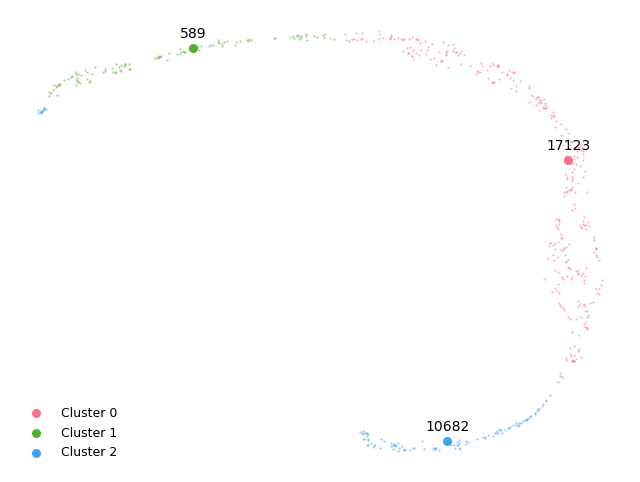

In [49]:
data_2d = data_2d_umap # this is the data for visualization
dim_name = 'umap'

#Getting unique labels
plt.figure(figsize=(8,6))
u_labels = np.unique(label)
num_labels = len(u_labels)
color_palette = sns.color_palette('husl', num_labels)
for i, each in enumerate(center_list):
    plt.scatter(data_2d[each][0],data_2d[each][1], s=30, c=[color_palette[i]])
    plt.annotate(center_list_annotation[i], (data_2d[each][0],data_2d[each][1]), ha="center", va="center", xytext=(0,10), textcoords='offset points')
for i in u_labels:
    plt.scatter(data_2d[label == i , 0] , data_2d[label == i , 1] , label=f"Cluster {i}", s=0.5, c=[color_palette[i]],alpha=0.4)
legend = plt.legend(loc='lower left', ncol=1, frameon=False)
for legend_handle in legend.legend_handles:
    legend_handle.set_sizes([30])  # Increase the size of legend dots    
    legend_handle.set_alpha(1)
plt.setp(legend.texts, fontsize='9')
plt.axis('off')
plt.savefig(f'MARL_{curr_data}_{dim_name}_{n_clusters}_kmeans.png')

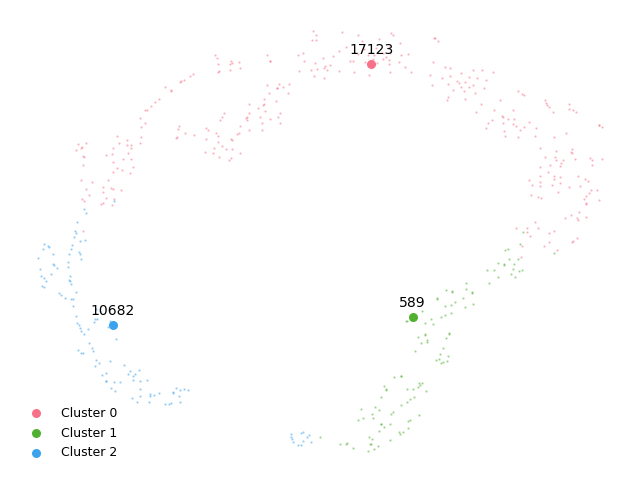

In [50]:
data_2d = data_2d_tsne # this is the data for visualization
dim_name = 'tsne'

#Getting unique labels
plt.figure(figsize=(8,6))
u_labels = np.unique(label)
num_labels = len(u_labels)
color_palette = sns.color_palette('husl', num_labels)
for i, each in enumerate(center_list):
    plt.scatter(data_2d[each][0],data_2d[each][1], s=30, c=[color_palette[i]])
    plt.annotate(center_list_annotation[i], (data_2d[each][0],data_2d[each][1]), ha="center", va="center", xytext=(0,10), textcoords='offset points')
for i in u_labels:
    plt.scatter(data_2d[label == i , 0] , data_2d[label == i , 1] , label=f"Cluster {i}", s=0.5, c=[color_palette[i]],alpha=0.4)
legend = plt.legend(loc='lower left', ncol=1, frameon=False)
for legend_handle in legend.legend_handles:
    legend_handle.set_sizes([30])  # Increase the size of legend dots 
    legend_handle.set_alpha(1)
plt.setp(legend.texts, fontsize='9')
plt.axis('off')
plt.savefig(f'MARL_{curr_data}_{dim_name}_{n_clusters}_kmeans.png')

## Visualize the cluster center

In [51]:
def scale_crop(img): #B,C,H,W
    rescale = transforms.Compose([transforms.Resize(112),
                                  transforms.CenterCrop(56)])
    return rescale(img)

In [52]:
indexes = center_list
cluster_count = n_clusters
print(f"Number of clusters: {cluster_count}, Number of indexes: {len(indexes)}")

Number of clusters: 3, Number of indexes: 3


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.091004156..0.49995002].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.09794882..0.49995002].


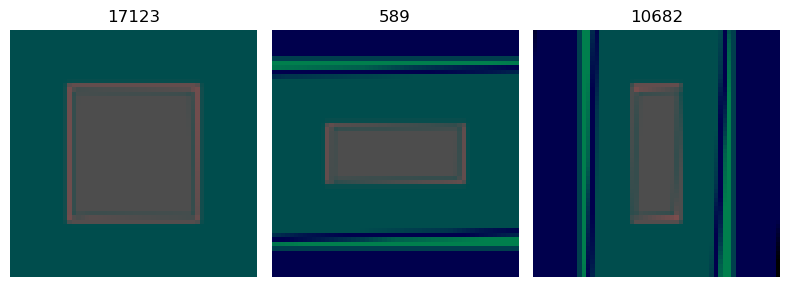

In [53]:
# Create a figure and axes with `cluster_count` subplots
fig, axes = plt.subplots(1, cluster_count, figsize=(8, 3))
image_size = 112
crop_size = 56

# Iterate over the `cluster_count` subplots
for i, index in enumerate(indexes):
    image_path = floor.all_data_dirs[index]
    # Read the image using torch's load
    image = torch.load(image_path)
    scaled = scale_crop(image)
    # Display the image in the corresponding subplot
    image_array = scaled.permute(1, 2, 0).numpy()  # Convert to (56, 56, 3) shape
    axes[i].imshow(image_array, cmap='gray')
    axes[i].set_title(os.path.basename(image_path).split(".")[0])
    axes[i].axis('off')

# Adjust the spacing between subplots
plt.tight_layout()

# Save the plot
plt.savefig(f"../results/recon_img/MARL_{curr_data}_{cluster_count}cluster_sample_multiscale.png")

In [54]:
def get_zoomed_img(image_path, half_pixel):
    image = mpimg.imread(image_path)
    # Get the center coordinates
    height, width, _ = image.shape
    center_x = width // 2
    center_y = height // 2
    
    # Calculate the coordinates for the center 150x150 pixels
    x1 = center_x - half_pixel
    x2 = center_x + half_pixel
    y1 = center_y - half_pixel
    y2 = center_y + half_pixel
    
    # Extract the center 150x150 pixels from each image
    center_img = image[y1:y2, x1:x2]
    return center_img

[17123, 589, 10682]

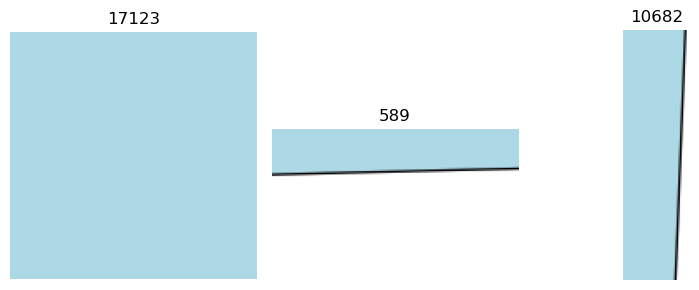

In [55]:
import os
import shutil
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

cluster_count = n_clusters
# Create a figure and axes with `cluster_count` subplots
fig, axes = plt.subplots(1, cluster_count, figsize=(8, 3))
image_size = 112
crop_size = 56
new_dir = 'kmeans_3_cluster'
num_indexes = []

if not os.path.exists(new_dir):
    os.makedirs(new_dir)

for i, index in enumerate(indexes):
    image_path = floor.all_data_dirs[index]
    # Split the path into the name and the extension
    file_name, file_extension = os.path.splitext(image_path)
    # Replace the '.pt' extension with '.png'
    png_file_path = file_name + '.png'
    # Read the image data
    img = get_zoomed_img(png_file_path, 75)
    # Display the image in the corresponding subplot
    axes[i].imshow(img, cmap='gray')
    # Extract numerical part from the file name
    num_index = int(os.path.basename(file_name))
    num_indexes.append(num_index)
    axes[i].set_title(f"{num_index}")
    axes[i].axis('off')

    # Add the prefix 'VQVAE_' to the original filename
    basename = os.path.basename(file_name)
    # Add the prefix 'VQVAE_' to the basename
    new_basename = f'MARL_{curr_data}_{basename}.png'
    # Copy the PNG file to the new directory with the modified filename
    shutil.copy(png_file_path, os.path.join(new_dir, new_basename))

# Adjust the spacing between subplots
plt.tight_layout()

# Save the plot
plt.savefig(f"../results/recon_img/MARL_{curr_data}_{cluster_count}cluster_sample.png")
num_indexes

In [56]:
import os
import shutil
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

cluster_count = n_clusters
image_size = 112
crop_size = 56

new_dir = 'kmeans_3_cluster'
num_indexes = []

# Create the output directory if it doesn't exist
if not os.path.exists(new_dir):
    os.makedirs(new_dir)

# Loop over each image and save it separately
for i, index in enumerate(indexes):
    image_path = floor.all_data_dirs[index]
    file_name, _ = os.path.splitext(image_path)
    png_file_path = file_name + '.png'

    # Load and process the image
    img = get_zoomed_img(png_file_path, 75)

    # Extract a short name or ID
    num_index = os.path.basename(file_name)
    num_indexes.append(num_index)

    # Compose new filename with prefix
    new_basename = f'MARL_{curr_data}_{index}.png'
    output_path = os.path.join(new_dir, new_basename)

    # Save the image (cmap='gray' is optional for grayscale)
    plt.imsave(output_path, img, cmap='gray')

print(f"Saved {len(indexes)} individual images to '{new_dir}/'")

num_indexes



Saved 3 individual images to 'kmeans_3_cluster/'


['17123', '589', '10682']

In [57]:
indexes = num_indexes
indexes

['17123', '589', '10682']

## calculate aggregated area

In [58]:
metadata_df = pd.read_csv("../data/data_config/tertiary/meta_trsa_tertiary.csv")
merged_df = pd.merge(df_center_index, metadata_df, left_on='index', right_on = 'OBJECTID', how='inner')
print(df_center_index.shape, merged_df.shape)
merged_df

(563, 2) (563, 7)


,label,index,OBJECTID,YearBuilt1,HEIGHT,UseDescription,GrossFloorArea
0,2,12840,12840,1947,12,5.0,378
1,0,7291,7291,1968,6,5.0,238
2,1,9230,9230,1960,6,5.0,2108
3,1,17195,17195,1936,6,5.0,157
4,0,22105,22105,1972,3,5.0,419
...,...,...,...,...,...,...,...
558,0,24599,24599,1970,3,5.0,748
559,1,10696,10696,1960,18,5.0,1044
560,0,12890,12890,1959,6,5.0,393
561,0,25814,25814,1998,9,5.0,351


In [59]:
grouped_df_lab = merged_df.groupby('YearBuilt1').size().reset_index(name='count')
grouped_df_lab.to_csv(f"{new_dir}/MARL_{curr_data}_{cluster_count}cluster_use_counts_5.csv", index=False)
grouped_df_lab


,YearBuilt1,count
0,1457,1
1,1880,6
2,1888,1
3,1890,1
4,1898,5
...,...,...
106,2017,1
107,2018,1
108,2019,1
109,2020,2


In [60]:
grouped_df = merged_df.groupby('UseDescription').size().reset_index(name='count')
grouped_df['index_png'] = df_center['index_png']
grouped_df.to_csv(f"{new_dir}/MARL_{curr_data}_{cluster_count}cluster_area_aggregation_5.csv")
grouped_df

,UseDescription,count,index_png
0,5.0,563,17123


In [61]:
#json_index = curr_data.split('_')[0].split('data')[1]
#print(json_index)
json_df = gpd.read_file(f'../data_pipeline/trusted_zone/preprocessed_data/cleaned_catastro.geojson', driver='GeoJSON')
json_df = json_df[['id','reference', 'beginning', 'numberOf_1', 'currentUse', 'value', 'geometry']]
json_df

/opt/anaconda3/lib/python3.10/site-packages/pyogrio/raw.py:198: RuntimeWarning: driver GeoJSON does not support open option DRIVER
  return ogr_read(


,id,reference,beginning,numberOf_1,currentUse,value,geometry
0,1,000102100DF29G,1983/01/01 00:00:00,1,3_industrial,358,"MULTIPOLYGON (((420774.444 4599501.713, 420761..."
1,2,000143600DG20A,1975/01/01 00:00:00,1,2_agriculture,119,"POLYGON ((415483.756 4602106.827, 415480.786 4..."
2,3,000209700DG10B,1970/01/01 00:00:00,2,2_agriculture,400,"POLYGON ((415872.348 4602263.374, 415873.678 4..."
3,4,000328800DG10D,1940/01/01 00:00:00,1,1_residential,347,"MULTIPOLYGON (((417802.282 4604608.306, 417795..."
4,5,000328900DG10D,1960/01/01 00:00:00,2,1_residential,366,"MULTIPOLYGON (((417827.94 4604600.5, 417823.94..."
...,...,...,...,...,...,...,...
25859,25860,9993014DF1999H,1970/01/01 00:00:00,1,4_2_retail,1738,"POLYGON ((419769.588 4598924.25, 419764.578 45..."
25860,25861,9993018DF1999H,1990/01/01 00:00:00,3,3_industrial,25681,"MULTIPOLYGON (((419801.418 4599158.72, 419791...."
25861,25862,9993020DF1999H,1979/01/01 00:00:00,1,3_industrial,16,"POLYGON ((419913.3 4599224.609, 419908.89 4599..."
25862,25863,9993022DF1999H,2006/01/01 00:00:00,2,3_industrial,12318,"POLYGON ((419818.071 4599309.36, 419818.271 45..."


In [62]:
df_center['Closest Point Index'] = num_indexes
df_center

,Cluster Center,Closest Point Index,index_png
0,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",17123,17123
1,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",589,589
2,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",10682,10682


In [63]:
df_center['Closest Point Index'] = df_center['Closest Point Index'].astype(int)
json_df['id'] = json_df['id'].astype(int)

center_metadata = pd.merge(df_center, json_df, left_on='Closest Point Index', right_on='id', how='inner')


In [64]:
center_metadata.to_csv(f"{new_dir}/MARL_{curr_data}_{cluster_count}cluster_metadata_5.csv")

## recon the cluster center and export metadata

In [65]:
kmeans.cluster_centers_.shape

(3, 37632)

(82, 3, 112, 112) -> 

In [66]:
truncated_centers = kmeans.cluster_centers_[:, :25088]
latent_centers = torch.from_numpy(truncated_centers.reshape(n_clusters, 32, 28, 28).astype('float32')).to(device)

# def show(img, title):
#     npimg = img.numpy()
#     fig = plt.imshow(np.transpose(npimg, (1,2,0)), interpolation='nearest')
#     fig.axes.get_xaxis().set_visible(False)
#     fig.axes.get_yaxis().set_visible(False)
#     fig.axes.set_title(title)
# plt.figure()  # Create a new plot
# show(torchvision.utils.make_grid(valid_recon.cpu().data) + 0.5, "VQ-VAE Reconstructed")
# plt.savefig(f"{n_clusters}_VQrecon.png", bbox_inches='tight')

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.15974772..1.3409711].


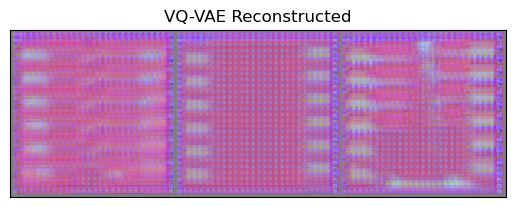

In [67]:
latent = vqae.pre_quantization_conv(latent_centers)
embedding_loss, latent, perplexity, _ = vqae.vector_quantization(latent)
x_hat = vqae.decoder(latent)
def show(img, title):
    npimg = img.numpy()
    fig = plt.imshow(np.transpose(npimg, (1,2,0)), interpolation='nearest')
    fig.axes.get_xaxis().set_visible(False)
    fig.axes.get_yaxis().set_visible(False)
    fig.axes.set_title(title)
plt.figure()  # Create a new plot
show(torchvision.utils.make_grid(x_hat.cpu().data) + 0.5, "VQ-VAE Reconstructed")
plt.savefig(f"../results/recon_img/MARL_{curr_data}_{cluster_count}cluster_center_recon_5.png", bbox_inches='tight')



In [68]:
latent.shape

torch.Size([3, 64, 28, 28])

In [69]:
valid_recon = vqae.pre_quantization_conv(latent_centers)
valid_recon.shape

torch.Size([3, 64, 28, 28])

In [70]:
valid_recon[0].shape

torch.Size([64, 28, 28])

# Visualize and Save Reconstruction Image

In [ ]:
floor.all_data_dirs[8834]

In [ ]:
kmeans.cluster_centers_.shape

In [ ]:
64*14*14

In [ ]:
latent_centers = torch.from_numpy(kmeans.cluster_centers_.reshape(n_clusters, 32, 28, 28).astype('float32')).to(device)
vqae.eval()
valid_recon = vqae.decoder(latent_centers)
def show(img, title):
    npimg = img.numpy()
    fig = plt.imshow(np.transpose(npimg, (1,2,0)), interpolation='nearest')
    fig.axes.get_xaxis().set_visible(False)
    fig.axes.get_yaxis().set_visible(False)
    fig.axes.set_title(title)
plt.figure()  # Create a new plot
show(torchvision.utils.make_grid(valid_recon.cpu().data) + 0.5, "VQ-VAE Reconstructed")
plt.savefig(f"{n_clusters}_VQrecon.png", bbox_inches='tight')

In [ ]:
def rescale_img(img): #B,C,H,W
    rescale = transforms.Compose([transforms.Resize(112),
                                  transforms.Pad(56, fill=1.0)])
    return rescale(img)
rescaled_recon = rescale_img(valid_recon+0.5)

for i in range(rescaled_recon.shape[0]):
    save_image(rescaled_recon[i], f'../results/recon_img/{n_clusters}cluster-img{i}.jpg')
    
print('save to results/recon_img/*.jpg')

### For rhino mapping-back 

In [ ]:
import glob
import cv2
import os
import numpy as np
import torchvision.transforms.functional as TF
import imageio
import matplotlib.pyplot as plt

In [ ]:
folder_path = "../results/recon_img/"  
img_files = []
for filename in os.listdir(folder_path):
    if "5cluster" in filename:
        print(filename)
        img_files.append(filename)

In [ ]:
def calc_height(image_path):
    print(image_path)
    fullpath = f"../results/recon_img/"+str(image_path)
    image = cv2.imread(fullpath)
    height, width, channels = image.shape
    print(height, width, channels)
    
    # Calculate the starting and ending indices for the central region
    start = (height - central_region_size) // 2
    end = start + central_region_size
    
    # Get the average pixel value in the central region for each channel
    central_region = image[start:end, start:end, :]
    average_pixel_value = np.mean(central_region, axis=(0,1))
    
    # Draw a red rectangle around the central region
    img_with_rectangle = np.copy(image)
    cv2.rectangle(img_with_rectangle, (start, start), (end, end), (0, 0, 255), 2)  # Draw red rectangle
    
    # Save the image with the red rectangle
    image_with_rectangle_path = fullpath.replace(".jpg", "_rectangle.jpg")  # Update the path as per your requirement
    imageio.imwrite(image_with_rectangle_path, img_with_rectangle)
    print(image_with_rectangle_path)
    return average_pixel_value

central_region_size = 10
height_info = []
for image_path in img_files:
    average_pixel_value = calc_height(image_path)
    height_info.append(average_pixel_value[0])

In [ ]:
height_info

In [ ]:
# Loop through each image
image_paths = glob.glob('recon_img/*.png')
lower_thres = 0.3
higher_thres = 0.7
for image_path in image_paths:
    image = cv2.imread(image_path)
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    gray = cv2.convertScaleAbs(gray)
    edges = cv2.Canny(gray, lower_thres, higher_thres)  # Adjust the threshold values as needed

    # Save the edge image
    filename = os.path.splitext(os.path.basename(image_path))[0]  # Extract the filename without extension
    edge_image_path = f'edge_img/{filename}_edge.jpg'
    cv2.imwrite(edge_image_path, edges)

### get aggregated area

In [ ]:
def get_csv_df(index):
    desired_number = str(index)
    for filename in os.listdir(directory_path):
        if desired_number in filename:
            file_path = os.path.join(directory_path, filename)
            csv_df = pd.read_csv(file_path,index_col=None)
            csv_df['index'] = csv_df['data'].str.extract(r'(\d+)\.pt')
            csv_df['index']=csv_df['index'].astype(int)
    return csv_df

In [ ]:
def calculate_aggregated_areas(csv_df):
    desired_features = []
    for feature in jsonfile['features']:
        if feature['properties']['OBJECTID'] in csv_df['index'].values:
            desired_features.append(feature)

    # Extract information for objectID, areas, and heights from desired features
    objectID_list = []
    footprint_list = []
    area_list = []
    height_list = []

    for feature in desired_features:
        objectID = feature['properties']['OBJECTID']
        footprint = feature['properties']['footprint']
        area = feature['properties']['Shape_Area_1']
        height = feature['properties']['HEIGHT']

        objectID_list.append(objectID)
        footprint_list.append(footprint)
        area_list.append(area)
        height_list.append(height)

        # Create a new DataFrame from the extracted information
        json_df = pd.DataFrame({
            'objectID': objectID_list,
            'footprint': footprint_list,
            'area': area_list,
            'height': height_list
        })
    merged_df = json_df.merge(csv_df, left_on='objectID', right_on='index')
    sum_of_area = merged_df['area'].sum()
    return sum_of_area, merged_df

In [ ]:
def get_sum_of_area():
    merged_df = csv_df.merge(objectid_ref_df, left_on='index', right_on='OBJECTID')
    print(f"csv_df shape = {csv_df.shape}, objectid_ref_df = {objectid_ref_df.shape}")
    print(f"merged_df shape = {merged_df.shape}")
    sum_of_area = merged_df['building.area.m2'].sum()
    return sum_of_area

In [ ]:
sum_of_area_list = []
json_file_path = r"..\data\data_root\geojson_0.json"
directory_path = r'../results/area_aggregation'  # Use r prefix for raw string
# Create an empty DataFrame to store the objectIDs
objectID_df = pd.DataFrame(columns=[0])
# Load the JSON data from the file
with open(json_file_path) as file:
    jsonfile = json.load(file)
    
for index in tqdm(num_indexes):
    csv_df = get_csv_df(index)
    # filtered_df = csv_df[csv_df['index'].isin(objectid_ref_df['OBJECTID'])]
    # print(filtered_df.shape)
    # sum_of_area, merged_df=calculate_aggregated_areas(filtered_df)
    sum_of_area = get_sum_of_area()
    sum_of_area_list.append(sum_of_area)
    # merged_df.to_csv(f'../results/area_aggregation/5cluster_{index}_merged.csv',index=False)
    # objectID_df = pd.concat([objectID_df, merged_df['objectID']], ignore_index=True)
# objectID_df.to_csv('../results/area_aggregation/objectID.csv', index=False)

In [ ]:
sum_of_area_list

In [ ]:
objectid_ref_df

In [ ]:
objectid_ref_df.sum()

In [ ]:
sum_of_area_list

In [ ]:
new_df = pd.DataFrame({'index': num_indexes, 'area': sum_of_area_list})
new_df.to_csv('area_aggregation_kmeans_5.csv')